In [11]:
import pandas as pd
import numpy as np

# ==================================================
# 1. Load Excel file
# ==================================================

file_path = "/storage/homefs/ge24z347/exposure_results_campgrounds/Muzzano_2m_v2/Muzzano_2m_v2_exposure.xlsx"

# Check available sheets
xls = pd.ExcelFile(file_path)
print("Available sheets:")
print(xls.sheet_names)

# Use the counts_long sheet
df = pd.read_excel(file_path, sheet_name="counts_long")

print("Columns in counts_long:")
print(df.columns)
display(df.head())

# ==================================================
# 2. Create total exposure percentage per rainfall intensity
# ==================================================

mobile_total = df["mobile_total"].dropna().iloc[0]
non_mobile_total = df["non_mobile_total"].dropna().iloc[0]
total_units = mobile_total + non_mobile_total

print("Mobile total:", mobile_total)
print("Non-mobile total:", non_mobile_total)
print("Total units:", total_units)

summary_df = (
    df.groupby("scenario", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "exposed_units_total"})
)

summary_df["percentage_affected_total"] = (
    summary_df["exposed_units_total"] / total_units * 100
)

summary_df = summary_df.sort_values("scenario").reset_index(drop=True)

print("Summary dataframe used for elbow method:")
display(summary_df)

# ==================================================
# 3. Perpendicular-distance functions
# ==================================================

def perpendicular_distances(df, start_row, end_row):
    """
    Calculate the perpendicular distance from each point (x_i, y_i)
    to the secant line connecting the start and end points.
    """

    x1 = start_row["scenario"]
    y1 = start_row["percentage_affected_total"]

    x2 = end_row["scenario"]
    y2 = end_row["percentage_affected_total"]

    xi = df["scenario"].values
    yi = df["percentage_affected_total"].values

    numerator = np.abs(
        (y2 - y1) * xi
        - (x2 - x1) * yi
        + x2 * y1
        - y2 * x1
    )

    denominator = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)

    return numerator / denominator


def get_previous_or_elbow(elbow_idx, start_idx, min_between=2):
    """
    Select the rainfall intensity immediately before the mathematical elbow
    only if there are enough rainfall intensities between the lower reference
    level and the elbow point.

    If fewer than `min_between` rainfall intensities exist between the lower
    reference level and the elbow, keep the mathematical elbow.

    Example:
    L1 = 15
    Mathematical elbow = 35
    Only one scenario between them: 25

    Since n_between = 1 and min_between = 2,
    the selected level remains 35.
    """

    n_between = elbow_idx - start_idx - 1

    if n_between >= min_between:
        return elbow_idx - 1
    else:
        return elbow_idx

# ==================================================
# 4. Define Level 1
# ==================================================

exposed_df = summary_df[summary_df["percentage_affected_total"] > 0].copy()

if exposed_df.empty:
    raise ValueError("No exposed units were found. L1 cannot be defined.")

level_1_idx = exposed_df.index[0]
level_1_row = summary_df.loc[level_1_idx]

# ==================================================
# 5. Main elbow: used to derive L3
# ==================================================

end_idx = summary_df.index[-1]
end_row = summary_df.loc[end_idx]

main_section = summary_df.loc[level_1_idx:end_idx].copy()

main_section["distance"] = perpendicular_distances(
    main_section,
    level_1_row,
    end_row
)

main_elbow_idx = main_section["distance"].idxmax()
main_elbow_row = summary_df.loc[main_elbow_idx]

# Apply the modified rule for L3
level_3_idx = get_previous_or_elbow(
    elbow_idx=main_elbow_idx,
    start_idx=level_1_idx,
    min_between=2
)

level_3_row = summary_df.loc[level_3_idx]

# ==================================================
# 6. Intermediate elbow: used to derive L2
# ==================================================

intermediate_section = summary_df.loc[level_1_idx:level_3_idx].copy()

intermediate_section["distance"] = perpendicular_distances(
    intermediate_section,
    level_1_row,
    level_3_row
)

intermediate_elbow_idx = intermediate_section["distance"].idxmax()
intermediate_elbow_row = summary_df.loc[intermediate_elbow_idx]

# Apply the same modified rule for L2
level_2_idx = get_previous_or_elbow(
    elbow_idx=intermediate_elbow_idx,
    start_idx=level_1_idx,
    min_between=2
)

level_2_row = summary_df.loc[level_2_idx]

# ==================================================
# 7. Create dataframe with selected warning levels
# ==================================================

levels_df = pd.DataFrame([
    {
        "impact_level": 1,
        "scenario": level_1_row["scenario"],
        "percentage_affected": level_1_row["percentage_affected_total"],
        "reference_elbow_scenario": np.nan,
        "reference_elbow_percentage_affected": np.nan
    },
    {
        "impact_level": 2,
        "scenario": level_2_row["scenario"],
        "percentage_affected": level_2_row["percentage_affected_total"],
        "reference_elbow_scenario": intermediate_elbow_row["scenario"],
        "reference_elbow_percentage_affected": intermediate_elbow_row["percentage_affected_total"]
    },
    {
        "impact_level": 3,
        "scenario": level_3_row["scenario"],
        "percentage_affected": level_3_row["percentage_affected_total"],
        "reference_elbow_scenario": main_elbow_row["scenario"],
        "reference_elbow_percentage_affected": main_elbow_row["percentage_affected_total"]
    }
])

# ==================================================
# 8. Print/check results
# ==================================================

print("Selected warning levels:")
display(levels_df)

print("Main mathematical elbow used for L3:")
display(main_elbow_row)

print("Intermediate mathematical elbow used for L2:")
display(intermediate_elbow_row)

print("Number of rainfall intensities between L1 and main elbow:")
print(main_elbow_idx - level_1_idx - 1)

print("Number of rainfall intensities between L1 and intermediate elbow:")
print(intermediate_elbow_idx - level_1_idx - 1)

# Optional: print clear summary
print("\nFinal selected levels:")
print(f"L1: {level_1_row['scenario']} mm/h "
      f"({level_1_row['percentage_affected_total']:.2f}% affected)")

print(f"L2: {level_2_row['scenario']} mm/h "
      f"({level_2_row['percentage_affected_total']:.2f}% affected)")

print(f"L3: {level_3_row['scenario']} mm/h "
      f"({level_3_row['percentage_affected_total']:.2f}% affected)")

print("\nReference mathematical elbows:")
print(f"Mathematical elbow for L2: {intermediate_elbow_row['scenario']} mm/h")
print(f"Mathematical elbow for L3: {main_elbow_row['scenario']} mm/h")

Available sheets:
['counts_long', 'counts_pivot', 'site_totals']
Columns in counts_long:
Index(['group', 'level', 'count', 'scenario', 'mobile_total',
       'non_mobile_total'],
      dtype='object')


,group,level,count,scenario,mobile_total,non_mobile_total
0,non_mobile,1,1,10,237,17
1,mobile,1,7,20,237,17
2,non_mobile,1,3,20,237,17
3,mobile,1,23,30,237,17
4,non_mobile,1,3,30,237,17


Mobile total: 237
Non-mobile total: 17
Total units: 254
Summary dataframe used for elbow method:


,scenario,exposed_units_total,percentage_affected_total
0,10,1,0.393701
1,20,10,3.937008
2,30,26,10.236220
3,40,30,11.811024
4,50,46,18.110236
5,60,87,34.251969
6,70,124,48.818898
7,80,149,58.661417


Selected warning levels:


...

Main mathematical elbow used for L3:


scenario                     50.000000
exposed_units_total          46.000000
percentage_affected_total    18.110236
Name: 4, dtype: float64

Intermediate mathematical elbow used for L2:


scenario                     30.00000
exposed_units_total          26.00000
percentage_affected_total    10.23622
Name: 2, dtype: float64

Number of rainfall intensities between L1 and main elbow:
3
Number of rainfall intensities between L1 and intermediate elbow:
1

Final selected levels:
L1: 10.0 mm/h (0.39% affected)
L2: 30.0 mm/h (10.24% affected)
L3: 40.0 mm/h (11.81% affected)

Reference mathematical elbows:
Mathematical elbow for L2: 30.0 mm/h
Mathematical elbow for L3: 50.0 mm/h


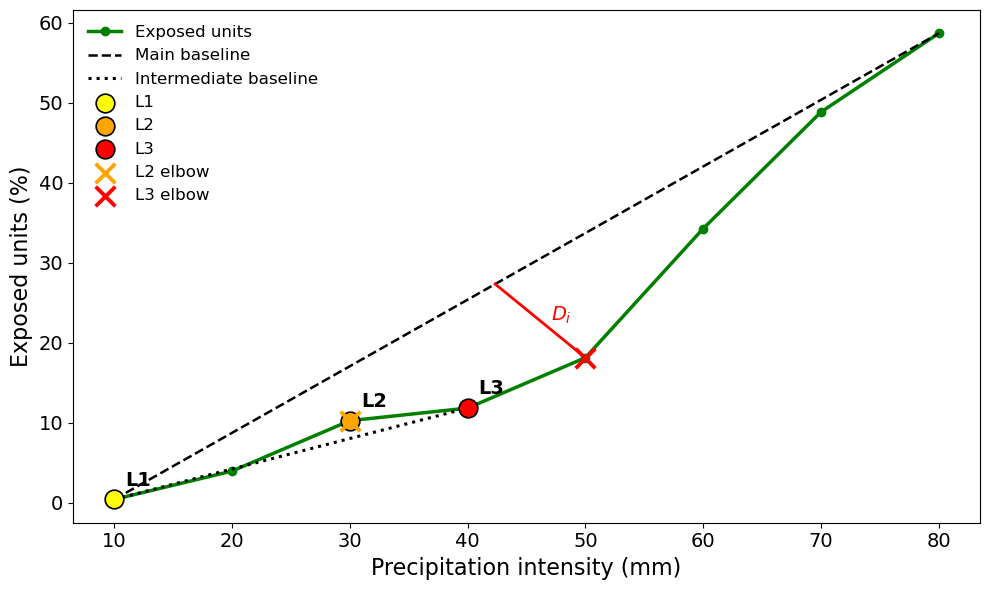

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --------------------------------------------------
# Plot preventive nested-elbow preparedness levels
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Make figure and axes background transparent
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# --------------------------------------------------
# Colors
# --------------------------------------------------
main_curve_color = "green"
reference_line_color = "black"

level_colors = {
    1: "yellow",
    2: "orange",
    3: "red"
}

# Elbow cross colors
intermediate_elbow_color = "orange"
main_elbow_color = "red"
distance_line_color = "red"

# --------------------------------------------------
# Main curve
# --------------------------------------------------
ax.plot(
    summary_df["scenario"],
    summary_df["percentage_affected_total"],
    marker="o",
    linewidth=2.5,
    color=main_curve_color,
    label="Exposed units"
)

# --------------------------------------------------
# Reference line for main elbow: Level 1 to maximum scenario
# --------------------------------------------------
x1_main = level_1_row["scenario"]
y1_main = level_1_row["percentage_affected_total"]
x2_main = summary_df.iloc[-1]["scenario"]
y2_main = summary_df.iloc[-1]["percentage_affected_total"]

ax.plot(
    [x1_main, x2_main],
    [y1_main, y2_main],
    linestyle="--",
    linewidth=1.8,
    color=reference_line_color,
    label="Main baseline"
)

# --------------------------------------------------
# Reference line for intermediate elbow: Level 1 to Level 3
# --------------------------------------------------
ax.plot(
    [level_1_row["scenario"], level_3_row["scenario"]],
    [level_1_row["percentage_affected_total"], level_3_row["percentage_affected_total"]],
    linestyle=":",
    linewidth=2.2,
    color=reference_line_color,
    label="Intermediate baseline"
)

# --------------------------------------------------
# Plot Level 1, Level 2, Level 3
# --------------------------------------------------
for _, row in levels_df.iterrows():

    impact_level = int(row["impact_level"])

    ax.scatter(
        row["scenario"],
        row["percentage_affected"],
        s=180,
        zorder=5,
        color=level_colors[impact_level],
        edgecolor="black",
        linewidth=1.2,
        label=f"L{impact_level}"
    )

    ax.annotate(
        f"L{impact_level}",
        xy=(row["scenario"], row["percentage_affected"]),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=14,
        fontweight="bold",
        color="black"
    )

# --------------------------------------------------
# Plot mathematical elbow reference points
# --------------------------------------------------

# Intermediate elbow used to derive Level 2
intermediate_elbow_scenario = levels_df.loc[
    levels_df["impact_level"] == 2,
    "reference_elbow_scenario"
].iloc[0]

intermediate_elbow_percentage = levels_df.loc[
    levels_df["impact_level"] == 2,
    "reference_elbow_percentage_affected"
].iloc[0]

if pd.notna(intermediate_elbow_scenario):
    ax.scatter(
        intermediate_elbow_scenario,
        intermediate_elbow_percentage,
        marker="x",
        s=200,
        linewidths=2.8,
        color=intermediate_elbow_color,
        zorder=6,
        label="L2 elbow"
    )

# Main elbow used to derive Level 3
main_elbow_scenario = levels_df.loc[
    levels_df["impact_level"] == 3,
    "reference_elbow_scenario"
].iloc[0]

main_elbow_percentage = levels_df.loc[
    levels_df["impact_level"] == 3,
    "reference_elbow_percentage_affected"
].iloc[0]

if pd.notna(main_elbow_scenario):
    ax.scatter(
        main_elbow_scenario,
        main_elbow_percentage,
        marker="x",
        s=200,
        linewidths=2.8,
        color=main_elbow_color,
        zorder=6,
        label="L3 elbow"
    )

    # --------------------------------------------------
    # Perpendicular distance from L3 elbow to main baseline
    # --------------------------------------------------
    A = np.array([x1_main, y1_main])   # start of main baseline
    B = np.array([x2_main, y2_main])   # end of main baseline
    P = np.array([main_elbow_scenario, main_elbow_percentage])  # elbow point

    AB = B - A
    AP = P - A

    # Projection of P onto line AB
    t = np.dot(AP, AB) / np.dot(AB, AB)
    Q = A + t * AB   # projected point on the baseline

    # Plot perpendicular line
    ax.plot(
        [P[0], Q[0]],
        [P[1], Q[1]],
        linestyle="-",
        linewidth=2,
        color=distance_line_color,
        zorder=4
    )

    # Annotate D_i near the middle of the perpendicular line
    mid_x = (P[0] + Q[0]) / 2
    mid_y = (P[1] + Q[1]) / 2

    ax.annotate(
        r"$D_i$",
        xy=(mid_x, mid_y),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=14,
        fontweight="bold",
        color=distance_line_color
    )

# --------------------------------------------------
# Figure settings
# --------------------------------------------------
ax.set_xlabel("Precipitation intensity (mm)", fontsize=16)
ax.set_ylabel("Exposed units (%)", fontsize=16)
ax.set_title("")

# Set x-axis ticks
ax.set_xticks(summary_df["scenario"])

# Increase tick font size
ax.tick_params(axis="both", which="major", labelsize=14)

# Remove background grid lines
ax.grid(False)

# Avoid duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    loc="best",
    frameon=False,
    fontsize=12
)

plt.tight_layout()

# --------------------------------------------------
# Save transparent figure
# --------------------------------------------------
plt.savefig(
    "preparedness_nested_elbow_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

In [ ]:
###line in red perpendicular

Original levels_df:
   impact_level  scenario  percentage_affected  reference_elbow_scenario  \
0             1      10.0             0.393701                       NaN   
1             2      30.0            10.236220                      30.0   
2             3      40.0            11.811024                      50.0   

   reference_elbow_percentage_affected  
0                                  NaN  
1                            10.236220  
2                            18.110236  

Levels used for plotting circles:
   impact_level  scenario  percentage_affected  reference_elbow_scenario  \
0             1      10.0             0.393701                       NaN   
1             2      20.0             3.937008                      30.0   
2             3      40.0            11.811024                      50.0   

   reference_elbow_percentage_affected  
0                                  NaN  
1                            10.236220  
2                            18.110236  


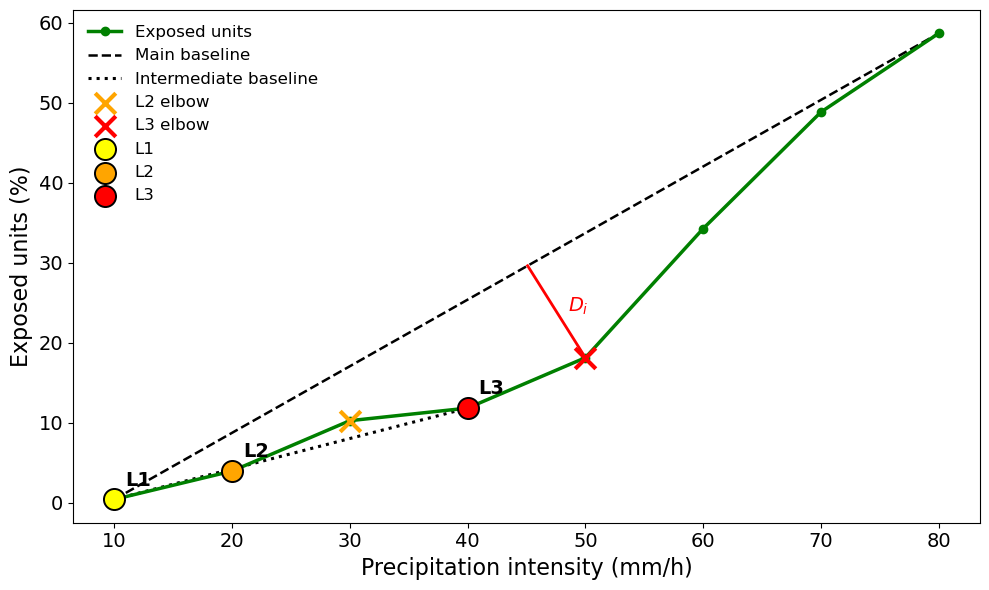

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --------------------------------------------------
# Helper function: assign previous available scenario
# --------------------------------------------------
def get_previous_scenario(elbow_scenario, available_scenarios):
    """
    Returns the previous precipitation intensity before the mathematical elbow.
    Example:
        elbow = 30, available = [10, 20, 30, 40, 50]
        returns 20
    """
    available_scenarios = np.array(sorted(available_scenarios))

    previous = available_scenarios[available_scenarios < elbow_scenario]

    if len(previous) == 0:
        return elbow_scenario

    return previous[-1]


# --------------------------------------------------
# Make plotting version of levels_df
# --------------------------------------------------
levels_plot_df = levels_df.copy()

available_scenarios = summary_df["scenario"].values

# Move L2 and L3 circles to the previous precipitation intensity
for impact_level in [2, 3]:

    idx = levels_plot_df["impact_level"] == impact_level

    elbow_scenario = levels_plot_df.loc[idx, "reference_elbow_scenario"].iloc[0]

    if pd.notna(elbow_scenario):

        previous_scenario = get_previous_scenario(
            elbow_scenario,
            available_scenarios
        )

        previous_percentage = summary_df.loc[
            summary_df["scenario"] == previous_scenario,
            "percentage_affected_total"
        ].iloc[0]

        levels_plot_df.loc[idx, "scenario"] = previous_scenario
        levels_plot_df.loc[idx, "percentage_affected"] = previous_percentage


print("Original levels_df:")
print(levels_df)

print("\nLevels used for plotting circles:")
print(levels_plot_df)


# --------------------------------------------------
# Plot preventive nested-elbow preparedness levels
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_alpha(0)
ax.set_facecolor("none")

# --------------------------------------------------
# Colors
# --------------------------------------------------
main_curve_color = "green"
reference_line_color = "black"

level_colors = {
    1: "yellow",
    2: "orange",
    3: "red"
}

intermediate_elbow_color = "orange"
main_elbow_color = "red"
distance_line_color = "red"

# --------------------------------------------------
# Main curve
# --------------------------------------------------
ax.plot(
    summary_df["scenario"],
    summary_df["percentage_affected_total"],
    marker="o",
    linewidth=2.5,
    color=main_curve_color,
    label="Exposed units",
    zorder=2
)

# --------------------------------------------------
# Extract plotting level rows
# --------------------------------------------------
level_1_plot = levels_plot_df.loc[levels_plot_df["impact_level"] == 1].iloc[0]
level_2_plot = levels_plot_df.loc[levels_plot_df["impact_level"] == 2].iloc[0]
level_3_plot = levels_plot_df.loc[levels_plot_df["impact_level"] == 3].iloc[0]

# --------------------------------------------------
# Main baseline: Level 1 to maximum scenario
# --------------------------------------------------
x1_main = level_1_plot["scenario"]
y1_main = level_1_plot["percentage_affected"]

x2_main = summary_df.iloc[-1]["scenario"]
y2_main = summary_df.iloc[-1]["percentage_affected_total"]

ax.plot(
    [x1_main, x2_main],
    [y1_main, y2_main],
    linestyle="--",
    linewidth=1.8,
    color=reference_line_color,
    label="Main baseline",
    zorder=1
)

# --------------------------------------------------
# Intermediate baseline: Level 1 to preventive Level 3
# --------------------------------------------------
ax.plot(
    [level_1_plot["scenario"], level_3_plot["scenario"]],
    [level_1_plot["percentage_affected"], level_3_plot["percentage_affected"]],
    linestyle=":",
    linewidth=2.2,
    color=reference_line_color,
    label="Intermediate baseline",
    zorder=1
)

# --------------------------------------------------
# Plot mathematical elbow reference points first
# --------------------------------------------------

# L2 mathematical elbow
intermediate_elbow_scenario = levels_df.loc[
    levels_df["impact_level"] == 2,
    "reference_elbow_scenario"
].iloc[0]

intermediate_elbow_percentage = levels_df.loc[
    levels_df["impact_level"] == 2,
    "reference_elbow_percentage_affected"
].iloc[0]

if pd.notna(intermediate_elbow_scenario):
    ax.scatter(
        intermediate_elbow_scenario,
        intermediate_elbow_percentage,
        marker="x",
        s=220,
        linewidths=3.0,
        color=intermediate_elbow_color,
        zorder=5,
        label="L2 elbow"
    )

# L3 mathematical elbow
main_elbow_scenario = levels_df.loc[
    levels_df["impact_level"] == 3,
    "reference_elbow_scenario"
].iloc[0]

main_elbow_percentage = levels_df.loc[
    levels_df["impact_level"] == 3,
    "reference_elbow_percentage_affected"
].iloc[0]

if pd.notna(main_elbow_scenario):
    ax.scatter(
        main_elbow_scenario,
        main_elbow_percentage,
        marker="x",
        s=220,
        linewidths=3.0,
        color=main_elbow_color,
        zorder=5,
        label="L3 elbow"
    )

    # --------------------------------------------------
    # Visually perpendicular distance from L3 elbow to main baseline
    # --------------------------------------------------
    fig.canvas.draw()

    A_data = np.array([x1_main, y1_main])
    B_data = np.array([x2_main, y2_main])
    P_data = np.array([main_elbow_scenario, main_elbow_percentage])

    A_disp = ax.transData.transform(A_data)
    B_disp = ax.transData.transform(B_data)
    P_disp = ax.transData.transform(P_data)

    AB_disp = B_disp - A_disp
    AP_disp = P_disp - A_disp

    t = np.dot(AP_disp, AB_disp) / np.dot(AB_disp, AB_disp)
    Q_disp = A_disp + t * AB_disp

    Q_data = ax.transData.inverted().transform(Q_disp)

    ax.plot(
        [P_data[0], Q_data[0]],
        [P_data[1], Q_data[1]],
        linestyle="-",
        linewidth=2,
        color=distance_line_color,
        zorder=4
    )

    mid_x = (P_data[0] + Q_data[0]) / 2
    mid_y = (P_data[1] + Q_data[1]) / 2

    ax.annotate(
        r"$D_i$",
        xy=(mid_x, mid_y),
        xytext=(8, 0),
        textcoords="offset points",
        fontsize=14,
        fontweight="bold",
        color=distance_line_color
    )

# --------------------------------------------------
# Plot preventive Level 1, Level 2, Level 3 circles
# --------------------------------------------------
for _, row in levels_plot_df.iterrows():

    impact_level = int(row["impact_level"])

    ax.scatter(
        row["scenario"],
        row["percentage_affected"],
        s=230,
        zorder=10,
        color=level_colors[impact_level],
        edgecolor="black",
        linewidth=1.4,
        label=f"L{impact_level}"
    )

    ax.annotate(
        f"L{impact_level}",
        xy=(row["scenario"], row["percentage_affected"]),
        xytext=(8, 10),
        textcoords="offset points",
        fontsize=14,
        fontweight="bold",
        color="black",
        zorder=11
    )

# --------------------------------------------------
# Figure settings
# --------------------------------------------------
ax.set_xlabel("Precipitation intensity (mm/h)", fontsize=16)
ax.set_ylabel("Exposed units (%)", fontsize=16)
ax.set_title("")

ax.set_xticks(summary_df["scenario"])

ax.tick_params(axis="both", which="major", labelsize=14)

ax.grid(False)

# Avoid duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    loc="best",
    frameon=False,
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "preparedness_nested_elbow_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()